In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

shap.initjs()

In [2]:
# Load model
xgb_model = joblib.load('../models/xgboost_churn.pkl')

# Load data preprocessed
df = pd.read_csv('../data/processed/data_preprocessed.csv')

X = df.drop(columns=['Churn'])
y = df['Churn']

print(f"Model loaded: {xgb_model}")
print(f"Shape X: {X.shape}")

Model loaded: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=-1,
              num_parallel_tree=None, ...)
Shape X: (9364, 18)


In [3]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X)

print(f"SHAP values shape: {shap_values.shape}")
print("SHAP explainer siap!")

SHAP values shape: (9364, 18)
SHAP explainer siap!


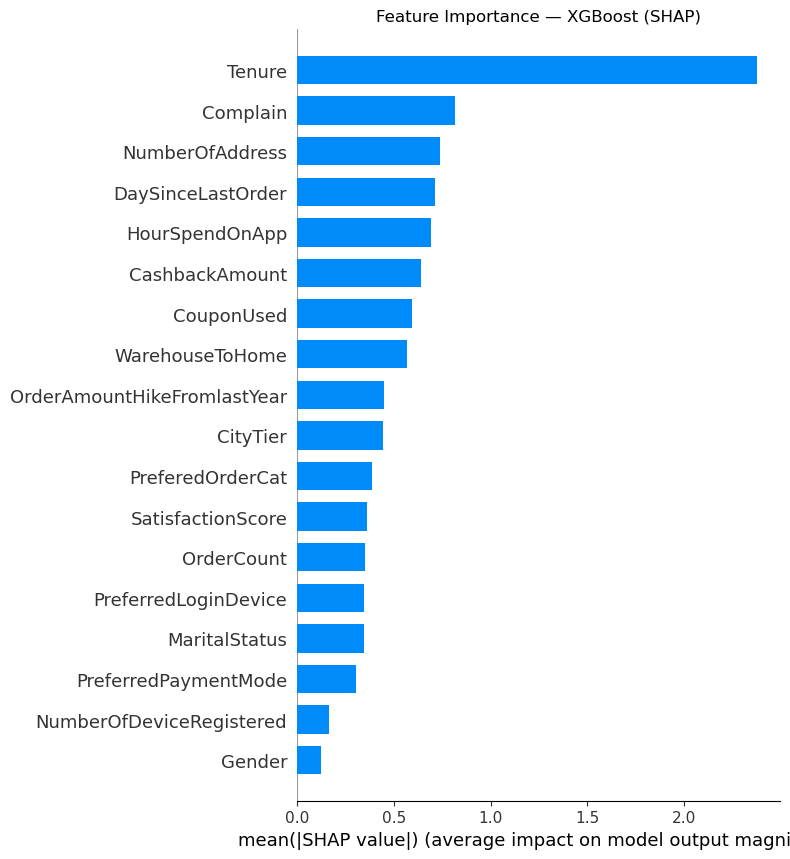

Plot tersimpan!


In [4]:
plt.figure()
shap.summary_plot(shap_values, X, plot_type='bar', show=False)
plt.title('Feature Importance — XGBoost (SHAP)')
plt.tight_layout()
plt.savefig('../models/shap_summary_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot tersimpan!")

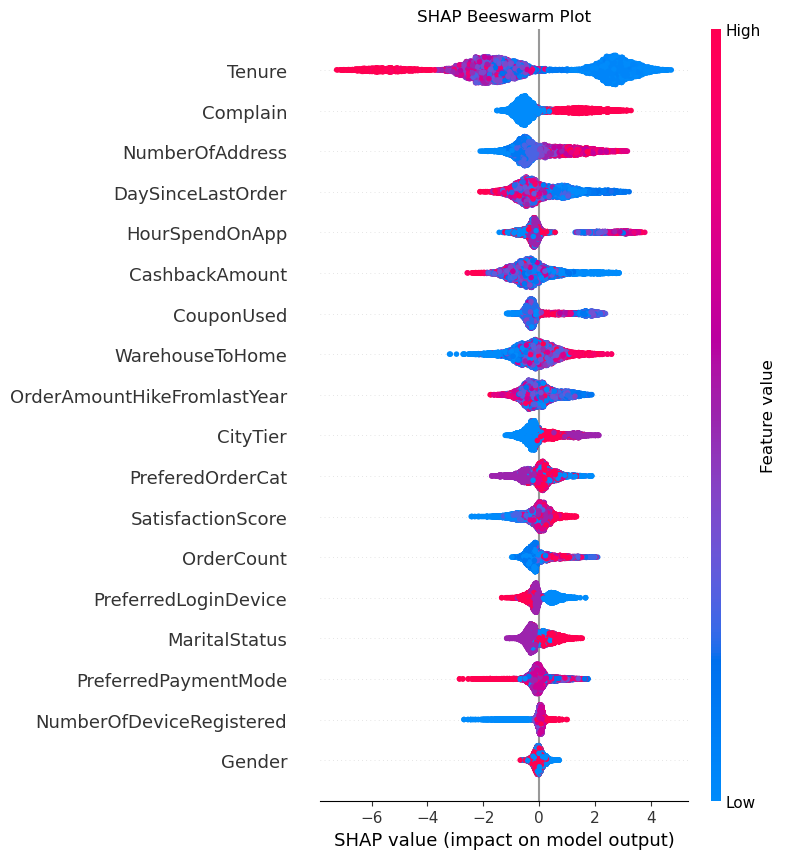

Plot tersimpan!


In [5]:
plt.figure()
shap.summary_plot(shap_values, X, show=False)
plt.title('SHAP Beeswarm Plot')
plt.tight_layout()
plt.savefig('../models/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot tersimpan!")

In [6]:
print("=" * 50)
print("SUMMARY EXPLAINABILITY")
print("=" * 50)
print(f"""
🔑 TOP 5 FITUR PALING BERPENGARUH (SHAP)
1. Tenure              — makin lama = makin loyal
2. Complain            — ada komplain = risiko churn tinggi
3. NumberOfAddress     — alamat banyak = tidak stabil
4. DaySinceLastOrder   — lama tidak order = risiko churn
5. HourSpendOnApp      — makin sering buka app = lebih loyal

💡 BUSINESS INSIGHT
- Fokus retensi pada pelanggan baru (tenure rendah)
- Tangani komplain dengan cepat sebelum churn
- Program cashback untuk pelanggan berisiko tinggi
- Re-engagement campaign untuk pelanggan yang
  lama tidak order

💾 PLOT TERSIMPAN
- models/shap_summary_bar.png
- models/shap_beeswarm.png
""")

SUMMARY EXPLAINABILITY

🔑 TOP 5 FITUR PALING BERPENGARUH (SHAP)
1. Tenure              — makin lama = makin loyal
2. Complain            — ada komplain = risiko churn tinggi
3. NumberOfAddress     — alamat banyak = tidak stabil
4. DaySinceLastOrder   — lama tidak order = risiko churn
5. HourSpendOnApp      — makin sering buka app = lebih loyal

💡 BUSINESS INSIGHT
- Fokus retensi pada pelanggan baru (tenure rendah)
- Tangani komplain dengan cepat sebelum churn
- Program cashback untuk pelanggan berisiko tinggi
- Re-engagement campaign untuk pelanggan yang
  lama tidak order

💾 PLOT TERSIMPAN
- models/shap_summary_bar.png
- models/shap_beeswarm.png

